In [1]:
import pandas as pd
import numpy as np 
from data.loader import Asset
from strategy.generator import strategyname, MeanReversionStrategy, TrendFollowingStrategy
from performance.backtest import Backtester
from performance.metrics import max_drawdown, buy_and_hold

In [2]:
config_data = pd.read_json("config.json")
stock = Asset(config_data)
stock.load_price_data()
stock.calculate_features()

In [3]:
MeanReversionStrategy(stock)()

               mean  count       sum
direction                           
-1.0       0.000770    610  0.469757
 0.0       0.009400      7  0.065797
 1.0      -0.000434    639 -0.277011


In [4]:
TrendFollowingStrategy(stock)()

               mean  count       sum
direction                           
-1.0       0.000770    610  0.469757
 0.0       0.009400      7  0.065797
 1.0      -0.000434    639 -0.277011


In [5]:
stock.data

,open,high,low,close,volume,dividends,stock splits,close_lag,ratio,return,return_lag,direction,mean_reversion_signal,trend_following_signal
Date,,,,,,,,,,,,,,
2019-01-02 00:00:00-05:00,39.554146,40.853685,39.390629,40.518044,18774600,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03 00:00:00-05:00,39.717675,39.829553,38.202979,38.289043,32267300,0.0,0.0,40.518044,0.944987,-0.056584,NaN,NaN,NaN,NaN
2019-01-04 00:00:00-05:00,39.450876,40.939751,39.192691,40.638535,35447300,0.0,0.0,38.289043,1.061362,0.059553,-0.056584,-1.0,1.0,-1.0
2019-01-07 00:00:00-05:00,40.535262,41.309822,40.234046,40.827873,22736800,0.0,0.0,40.638535,1.004659,0.004648,0.059553,1.0,-1.0,1.0
2019-01-08 00:00:00-05:00,41.137691,41.335633,40.259857,41.086056,22749200,0.0,0.0,40.827873,1.006324,0.006304,0.004648,1.0,-1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22 00:00:00-05:00,46.625551,47.523524,46.576212,47.365639,30095700,0.0,0.0,46.457798,1.019541,0.019353,0.028438,1.0,-1.0,1.0
2023-12-26 00:00:00-05:00,48.273479,49.852336,48.066255,49.832600,60287400,0.0,0.0,47.365639,1.052083,0.050772,0.019353,1.0,-1.0,1.0
2023-12-27 00:00:00-05:00,49.960882,50.602289,49.526694,50.089161,52148000,0.0,0.0,49.832600,1.005148,0.005135,0.050772,1.0,-1.0,1.0


win_rate:0.4984101748807631


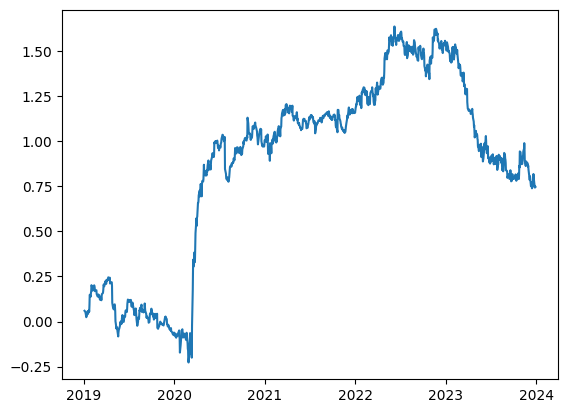

In [6]:
Backtester(stock.data, strategyname.MEAN_REVERSION).test()

win_rate:0.5111287758346582


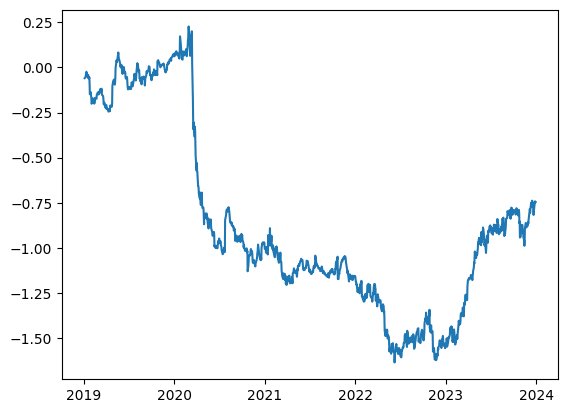

In [7]:
Backtester(stock.data, strategyname.TREND_FOLLOWING).test()

In [8]:
stock.data

,open,high,low,close,volume,dividends,stock splits,close_lag,ratio,return,return_lag,direction,mean_reversion_signal,trend_following_signal,mean_reversion_trade_return,mean_reversion_cumulative_trade_return,trend_following_trade_return,trend_following_cumulative_trade_return
Date,,,,,,,,,,,,,,,,,,
2019-01-02 00:00:00-05:00,39.554146,40.853685,39.390629,40.518044,18774600,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03 00:00:00-05:00,39.717675,39.829553,38.202979,38.289043,32267300,0.0,0.0,40.518044,0.944987,-0.056584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04 00:00:00-05:00,39.450876,40.939751,39.192691,40.638535,35447300,0.0,0.0,38.289043,1.061362,0.059553,-0.056584,-1.0,1.0,-1.0,0.059553,0.059553,-0.059553,-0.059553
2019-01-07 00:00:00-05:00,40.535262,41.309822,40.234046,40.827873,22736800,0.0,0.0,40.638535,1.004659,0.004648,0.059553,1.0,-1.0,1.0,-0.004648,0.054905,0.004648,-0.054905
2019-01-08 00:00:00-05:00,41.137691,41.335633,40.259857,41.086056,22749200,0.0,0.0,40.827873,1.006324,0.006304,0.004648,1.0,-1.0,1.0,-0.006304,0.048601,0.006304,-0.048601
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-22 00:00:00-05:00,46.625551,47.523524,46.576212,47.365639,30095700,0.0,0.0,46.457798,1.019541,0.019353,0.028438,1.0,-1.0,1.0,-0.019353,0.798142,0.019353,-0.798142
2023-12-26 00:00:00-05:00,48.273479,49.852336,48.066255,49.832600,60287400,0.0,0.0,47.365639,1.052083,0.050772,0.019353,1.0,-1.0,1.0,-0.050772,0.747369,0.050772,-0.747369
2023-12-27 00:00:00-05:00,49.960882,50.602289,49.526694,50.089161,52148000,0.0,0.0,49.832600,1.005148,0.005135,0.050772,1.0,-1.0,1.0,-0.005135,0.742234,0.005135,-0.742234


2022-06-08 00:00:00-04:00
2023-12-15 00:00:00-05:00


np.float64(-0.896784550515242)

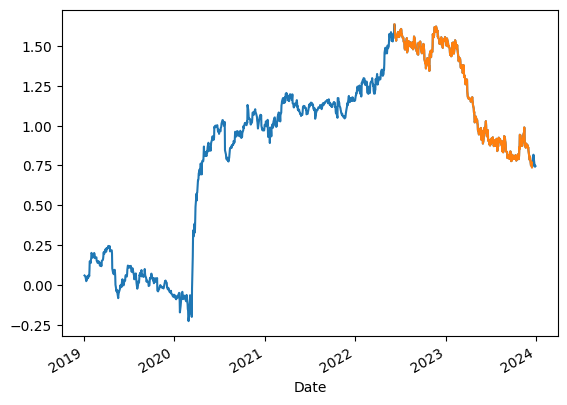

In [9]:
max_drawdown(stock.data, strategyname.MEAN_REVERSION)

2020-02-28 00:00:00-05:00
2022-06-08 00:00:00-04:00


np.float64(-1.8618943610411904)

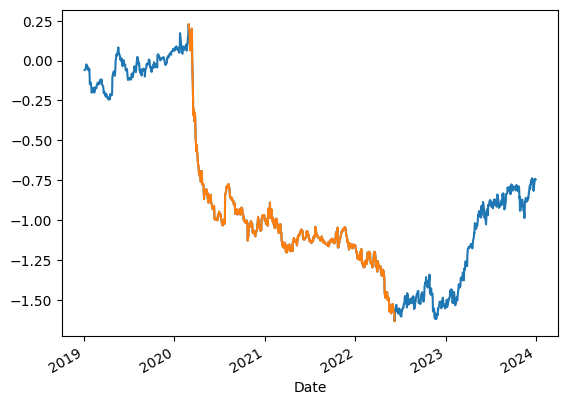

In [10]:
max_drawdown(stock.data, strategyname.TREND_FOLLOWING)

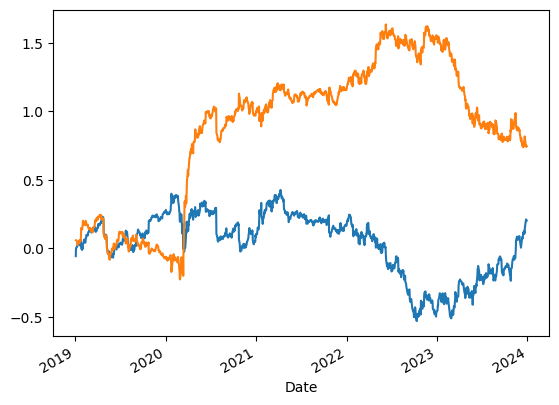

In [11]:
buy_and_hold(stock.data, strategyname.MEAN_REVERSION)

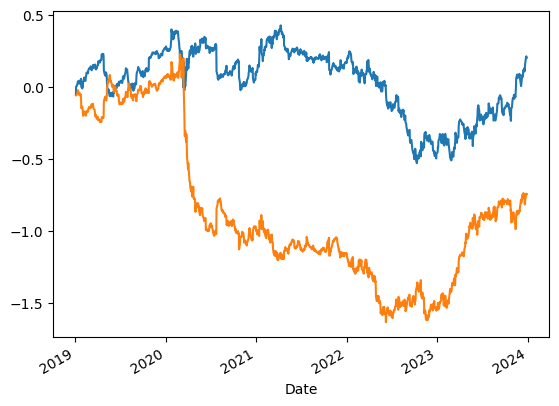

In [12]:
buy_and_hold(stock.data, strategyname.TREND_FOLLOWING)